In [ ]:
# IMPORT
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os



Saving Hamong tani_pages-to-jpg-0022.jpg to Hamong tani_pages-to-jpg-0022.jpg
Dimensi gambar: 2282x1457


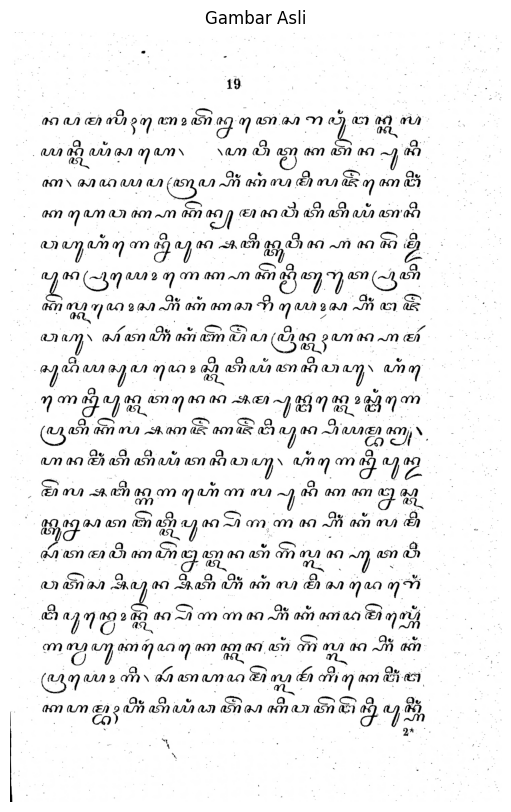

In [ ]:
# LOAD IMAGE
uploaded = files.upload()
path = list(uploaded.keys())[0]

img = cv2.imread(path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Menampilkan Gambar
print(f"Dimensi gambar: {h}x{w}")
plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

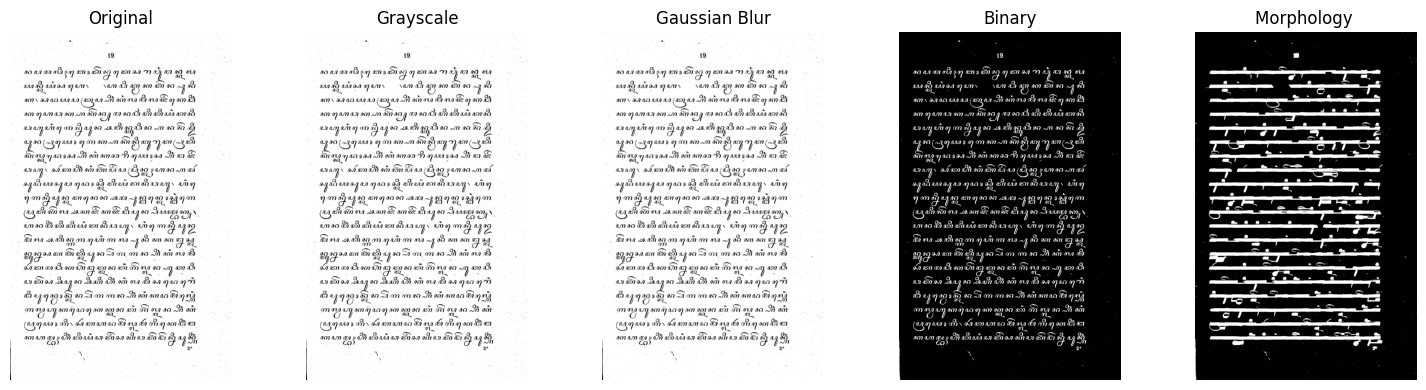

In [ ]:
# PREPROCESS
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # mengubah gambar dari format BGR ke grayscale (abu-abu)

# Gaussian Blur
denoise = cv2.GaussianBlur(gray, (3,3), 0)  # mengurangi noise pada gambar menggunakan Gaussian Blur dengan kernel 3x3

# threshold
_, bw = cv2.threshold(  # melakukan thresholding untuk mengubah gambar menjadi biner (hitam-putih)
    denoise, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# morphology horizontal
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30,1))  # membuat kernel berbentuk persegi panjang horizontal (lebar 30, tinggi 1)
clean = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)

# VISUALISASI PREPROCESSING
plt.figure(figsize=(15,4))

# Original
plt.subplot(1,5,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis('off')

# Grayscale
plt.subplot(1,5,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# Blur
plt.subplot(1,5,3)
plt.imshow(denoise, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

# Binary
plt.subplot(1,5,4)
plt.imshow(bw, cmap='gray')
plt.title("Binary")
plt.axis('off')

# Morphology
plt.subplot(1,5,5)
plt.imshow(clean, cmap='gray')
plt.title("Morphology ")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# PROJECTION
projection = np.sum(clean == 255, axis=1)

k = 20  # ukuran window untuk smoothing (jumlah data yang dirata-ratakan)
kernel_avg = np.ones(k) / k  # membuat kernel rata-rata (moving average) dengan nilai yang dijumlahkan = 1
smooth = np.convolve(projection, kernel_avg, mode='same')  # melakukan smoothing pada data projection menggunakan konvolusi



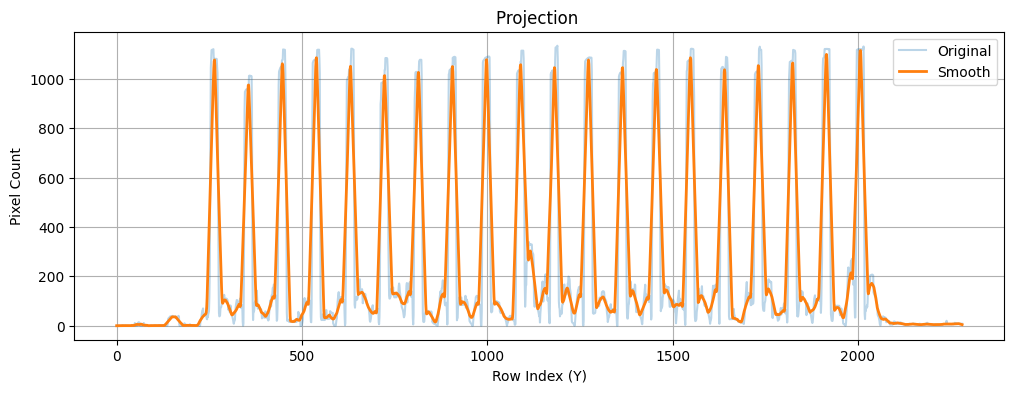

In [ ]:
# VISUALISASI
plt.figure(figsize=(12,4))

plt.plot(np.arange(h), projection, alpha=0.3, label='Original')
plt.plot(np.arange(h), smooth, linewidth=2, label='Smooth')

plt.title("Projection ")
plt.xlabel("Row Index (Y)")
plt.ylabel("Pixel Count")

plt.legend()
plt.grid()
plt.show()



In [ ]:
# PEAK DETECTION
candidates = []

for i in range(2, len(smooth)-2):
    window = smooth[i-2:i+3]

    # kondisi lokal maksimum
    if smooth[i] == max(window) and smooth[i] > np.mean(smooth):
        candidates.append(i)

candidates = np.array(candidates)

# ranking berdasarkan tinggi peak
if len(candidates) > 21:
    vals = smooth[candidates]
    top_idx = np.argsort(vals)[-21:]
    candidates = candidates[top_idx]

peaks = np.sort(candidates)

print("Jumlah baris:", len(peaks))



Jumlah baris: 21


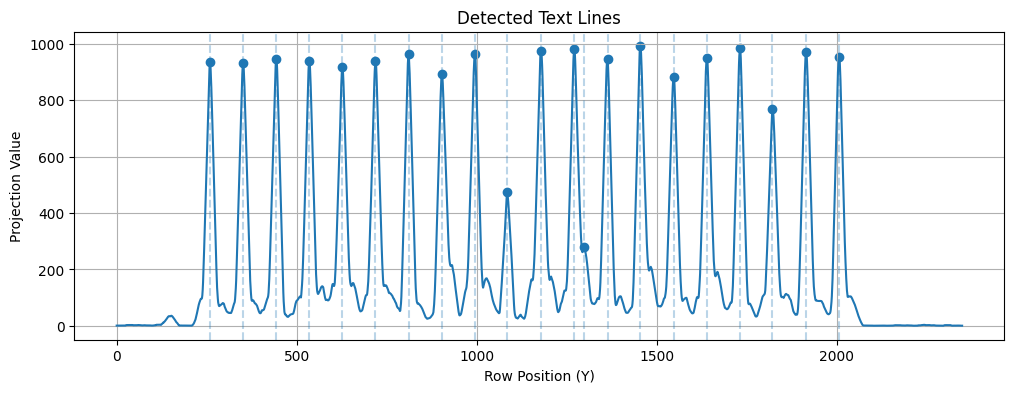

In [ ]:
# VISUALISASI PEAK
plt.figure(figsize=(12,4))

plt.plot(np.arange(h), smooth)
plt.scatter(peaks, smooth[peaks])

# garis vertikal untuk tiap peak
for p in peaks:
    plt.axvline(p, linestyle='--', alpha=0.3)

plt.title("Detected Text Lines")
plt.xlabel("Row Position (Y)")
plt.ylabel("Projection Value")

plt.grid()
plt.show()


In [ ]:
# BOUNDARY ANTAR BARIS
cuts = [0]

for i in range(len(peaks)-1):
    mid = int((peaks[i] + peaks[i+1]) / 2)
    cuts.append(mid)

cuts.append(h)



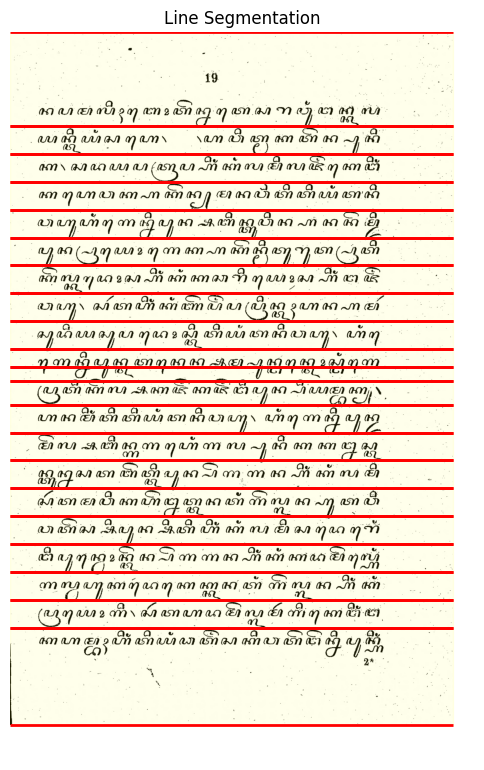

In [ ]:
# VISUALISASI SEGMENTASI
plt.figure(figsize=(6,10))
plt.imshow(rgb)

for i in range(len(cuts)-1):
    y1, y2 = cuts[i], cuts[i+1]

    plt.hlines([y1, y2], 0, w, colors='red', linewidth=2)
    plt.fill_betweenx([y1, y2], 0, w, color='yellow', alpha=0.08)

plt.title("Line Segmentation")
plt.axis('off')
plt.show()



In [ ]:
# CROP HASIL
os.makedirs("hasil_baris", exist_ok=True)

lines = []

for i in range(len(cuts)-1):
    y1, y2 = cuts[i], cuts[i+1]
    seg = rgb[y1:y2, :]
    lines.append(seg)

    cv2.imwrite(
        f"hasil_baris/line_{i+1}.png",
        cv2.cvtColor(seg, cv2.COLOR_RGB2BGR)
    )



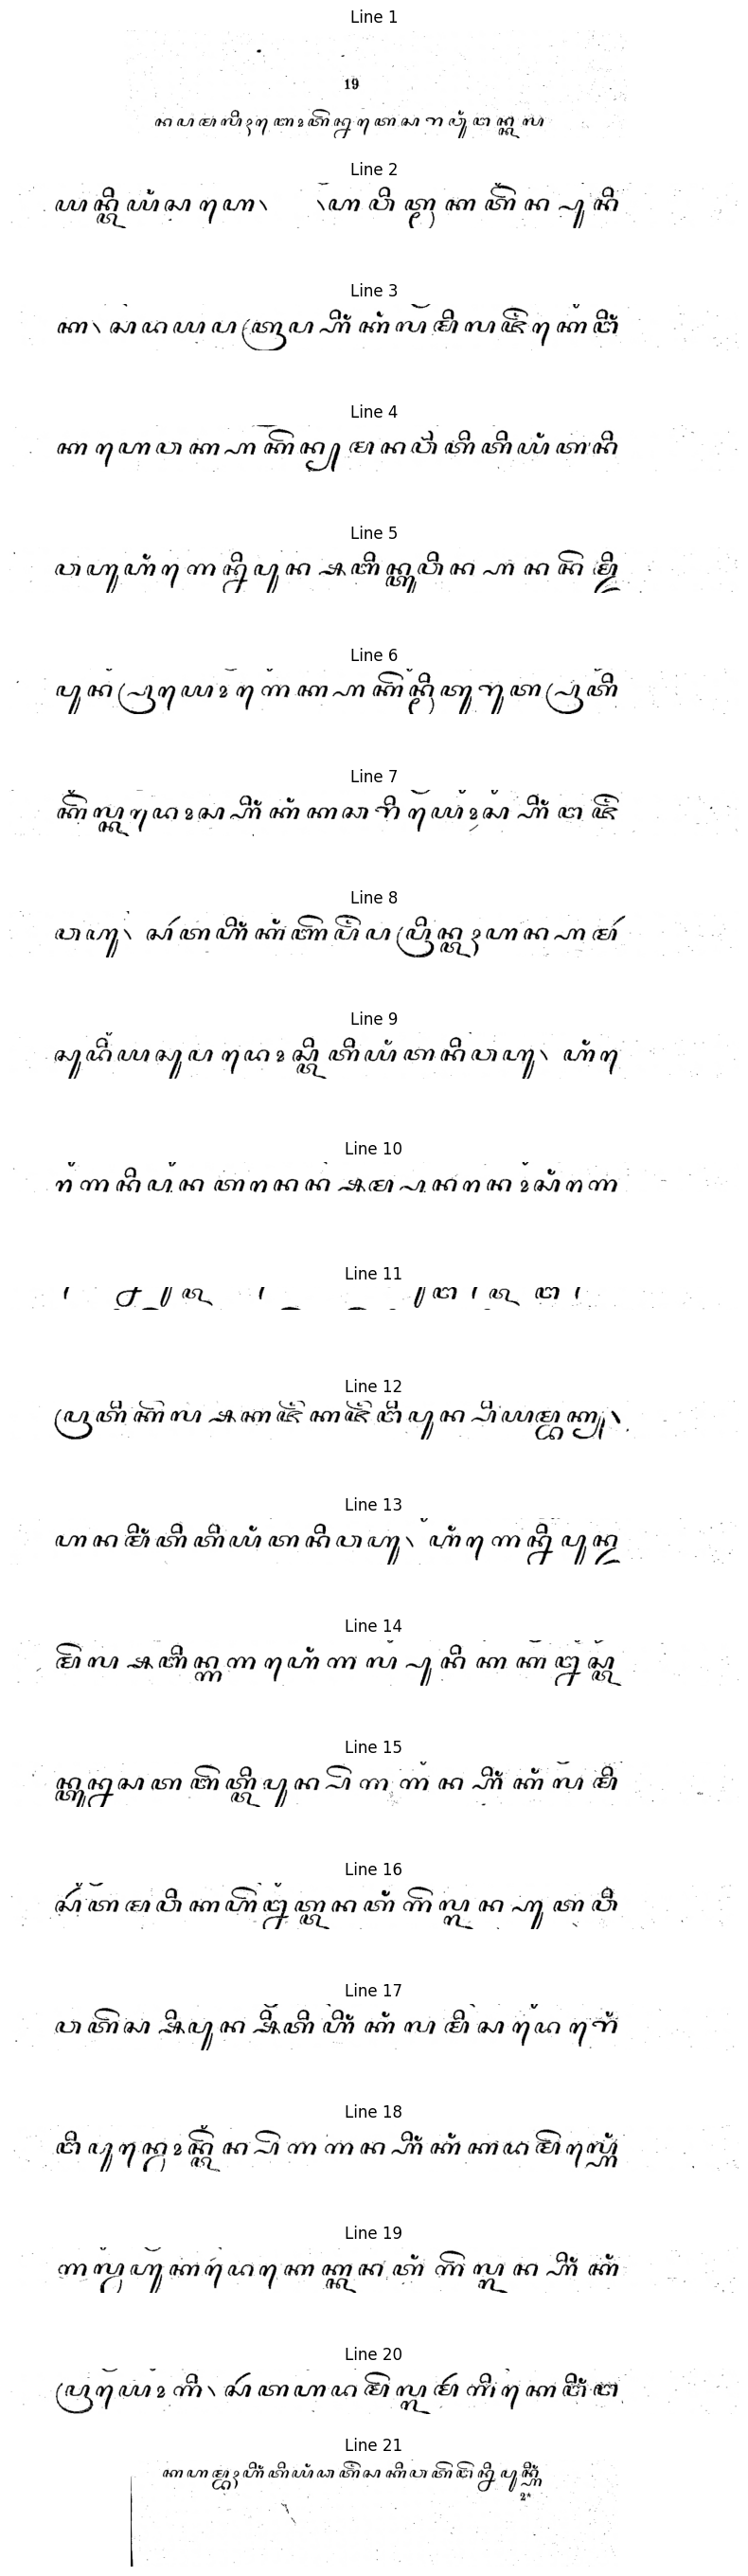

In [ ]:
# TAMPILKAN HASIL
plt.figure(figsize=(8, len(lines)*1.3))

for i, l in enumerate(lines):
    plt.subplot(len(lines),1,i+1)
    plt.imshow(l)
    plt.title(f"Line {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()



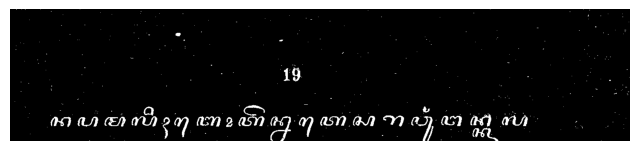

In [ ]:
# CONTOH 1 BARIS
sample = lines[0]

gray_line = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)
_, bin_line = cv2.threshold(
    gray_line, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8,2))
plt.imshow(bin_line, cmap='gray')
plt.axis('off')
plt.show()

# SEGMENTASI HURUF

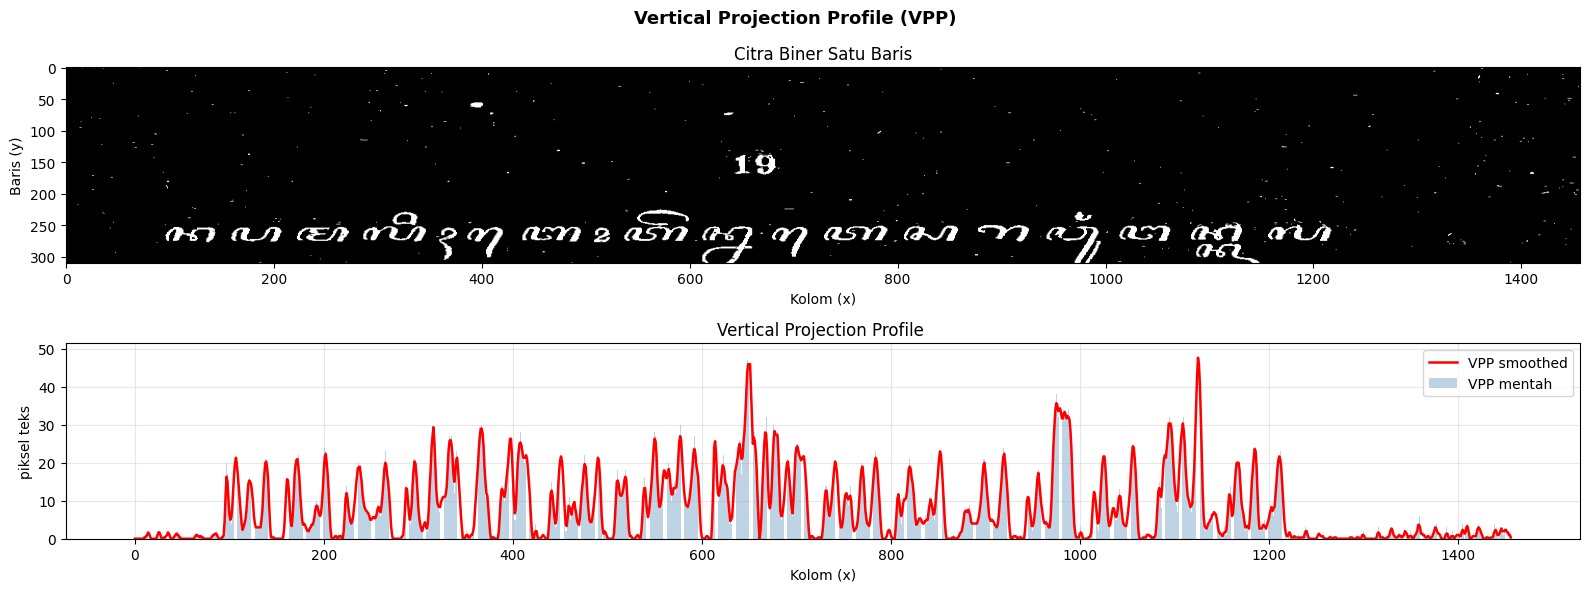

Lebar baris : 1457 kolom
VPP  min=0, max=49, rata=8.1


In [ ]:
# TAHAP 1 — VERTICAL PROJECTION PROFILE (VPP)
# Hitung jumlah piksel teks per KOLOM

# Hitung VPP: jumlah piksel putih (teks) per kolom
vpp = np.sum(bin_line == 255, axis=0)

# Smoothing VPP
k_smooth = 3
kernel_avg = np.ones(k_smooth) / k_smooth
vpp_smooth = np.convolve(vpp, kernel_avg, mode='same')

# Visualisasi citra baris + VPP
fig, axes = plt.subplots(2, 1, figsize=(16, 6),
                          gridspec_kw={'height_ratios': [2, 2]})
fig.suptitle('Vertical Projection Profile (VPP)', fontsize=13, fontweight='bold')

axes[0].imshow(bin_line, cmap='gray', aspect='auto')
axes[0].set_title('Citra Biner Satu Baris')
axes[0].set_xlabel('Kolom (x)')
axes[0].set_ylabel('Baris (y)')

x_cols = np.arange(len(vpp))
axes[1].bar(x_cols, vpp, color='steelblue', alpha=0.35, label='VPP mentah')
axes[1].plot(x_cols, vpp_smooth, color='red', linewidth=1.8, label='VPP smoothed')
axes[1].set_title('Vertical Projection Profile ')
axes[1].set_xlabel('Kolom (x)')
axes[1].set_ylabel('piksel teks')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Lebar baris : {bin_line.shape[1]} kolom")
print(f"VPP  min={vpp.min()}, max={vpp.max()}, rata={vpp.mean():.1f}")




In [ ]:
# TAHAP 2 — DETEKSI PER HURUF

THRESHOLD_RATIO = 0.05
MIN_CHAR_WIDTH  = 8
MIN_GAP         = 2

threshold_val = THRESHOLD_RATIO * vpp_smooth.max()
is_valley = vpp_smooth <= threshold_val

# STEP 2A segmentasi awal
segments = []
in_char = False

for col in range(len(is_valley)):
    if not is_valley[col] and not in_char:
        x_start = col
        in_char = True
    elif is_valley[col] and in_char:
        x_end = col
        if (x_end - x_start) >= MIN_CHAR_WIDTH:
            segments.append((x_start, x_end))
        in_char = False

if in_char:
    x_end = len(is_valley)
    if (x_end - x_start) >= MIN_CHAR_WIDTH:
        segments.append((x_start, x_end))

# merge gap kecil
merged = []
for seg in segments:
    if merged and (seg[0] - merged[-1][1]) < MIN_GAP:
        merged[-1] = (merged[-1][0], seg[1])
    else:
        merged.append(list(seg))

# STEP 2B — HITUNG UPPER BOUND (untuk deteksi huruf menyatu)
widths = [xe - xs for xs, xe in merged]

q1  = np.percentile(widths, 25)
q3  = np.percentile(widths, 75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# STEP 2C — SPLIT

def split_merged(bin_img, xs, xe, upper_bound, depth=0):
    if (xe - xs) <= upper_bound or depth > 3:
        return [(xs, xe)]

    sub_vpp = np.sum(bin_img[:, xs:xe] == 255, axis=0).astype(float)

    center_start = len(sub_vpp) // 4
    center_end   = 3 * len(sub_vpp) // 4
    sub_center   = sub_vpp[center_start:center_end]

    if len(sub_center) == 0:
        return [(xs, xe)]

    local_min = np.argmin(sub_center) + center_start
    split_col = xs + local_min

    left  = split_merged(bin_img, xs,        split_col, upper_bound, depth+1)
    right = split_merged(bin_img, split_col, xe,        upper_bound, depth+1)

    return left + right

# SPLIT
fixed_segments = []
for xs, xe in merged:
    if (xe - xs) > upper_bound:
        fixed_segments.extend(split_merged(bin_line, xs, xe, upper_bound))
    else:
        fixed_segments.append((xs, xe))

# STEP 2D — FILTER SEGMENT KECIL

fixed_segments = [(xs, xe) for xs, xe in fixed_segments
                  if (xe - xs) >= MIN_CHAR_WIDTH]

print(f"\nThreshold VPP : {threshold_val:.1f}")
print(f"Jumlah karakter : {len(fixed_segments)}")


Threshold VPP : 2.4
Jumlah karakter : 20


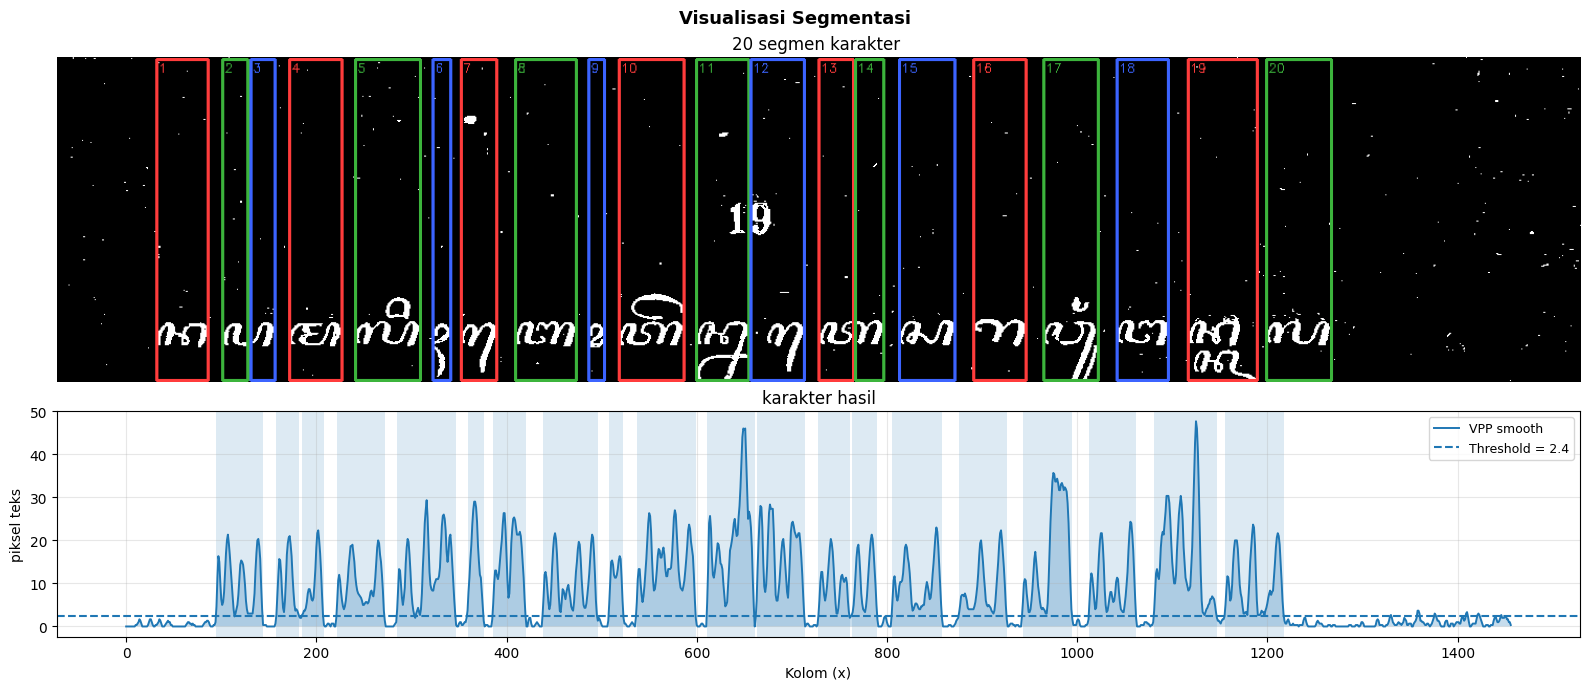

In [ ]:
# TAHAP 3 — VISUALISASI

fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                          gridspec_kw={'height_ratios': [3, 2]})
fig.suptitle('Visualisasi Segmentasi', fontsize=13, fontweight='bold')

img_vis = cv2.cvtColor(bin_line, cv2.COLOR_GRAY2RGB)
colors_box = [(255, 60, 60), (60, 180, 60), (60, 100, 255)]

for i, (xs, xe) in enumerate(fixed_segments):
    c = colors_box[i % len(colors_box)]
    cv2.rectangle(img_vis, (xs, 2), (xe, bin_line.shape[0]-2), c, 2)
    cv2.putText(img_vis, str(i+1), (xs+2, 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.38, c, 1)

axes[0].imshow(img_vis)
axes[0].set_title(f'{len(fixed_segments)} segmen karakter ')
axes[0].axis('off')

# Panel bawah
axes[1].fill_between(x_cols, vpp_smooth, alpha=0.25)
axes[1].plot(x_cols, vpp_smooth, linewidth=1.4, label='VPP smooth')
axes[1].axhline(threshold_val, linestyle='--', label=f'Threshold = {threshold_val:.1f}')

for xs, xe in fixed_segments:
    axes[1].axvspan(xs, xe, alpha=0.15)

axes[1].set_xlabel('Kolom (x)')
axes[1].set_ylabel('piksel teks')
axes[1].legend(fontsize=9)
axes[1].set_title('karakter hasil')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# TAHAP 4 — CROP SETIAP KARAKTER

os.makedirs("hasil_huruf", exist_ok=True)

TARGET_SIZE = (64, 64)

char_imgs  = []
char_info  = []

# crop vertikal
row_proj     = np.sum(bin_line == 255, axis=1)
nonzero_rows = np.where(row_proj > 0)[0]

if len(nonzero_rows) > 0:
    y_top = max(0, nonzero_rows[0] - 2)
    y_bot = min(bin_line.shape[0], nonzero_rows[-1] + 2)
else:
    y_top, y_bot = 0, bin_line.shape[0]

for idx, (xs, xe) in enumerate(fixed_segments):

    char_crop = bin_line[y_top:y_bot, xs:xe]

    h_c, w_c = char_crop.shape
    pad = abs(h_c - w_c) // 2

    if h_c > w_c:
        char_pad = cv2.copyMakeBorder(char_crop, 4, 4, pad+4, pad+4,
                                      cv2.BORDER_CONSTANT, value=0)
    else:
        char_pad = cv2.copyMakeBorder(char_crop, pad+4, pad+4, 4, 4,
                                      cv2.BORDER_CONSTANT, value=0)

    char_resized = cv2.resize(char_pad, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    fname = f"hasil_huruf/char_{idx+1:03d}.png"
    cv2.imwrite(fname, char_resized)

    char_imgs.append(char_resized)
    char_info.append({
        'idx'     : idx + 1,
        'x_start' : xs,
        'x_end'   : xe,
        'width'   : xe - xs,
        'file'    : fname
    })

print(f"\n{len(char_imgs)} karakter disimpan di folder")


20 karakter disimpan di folder


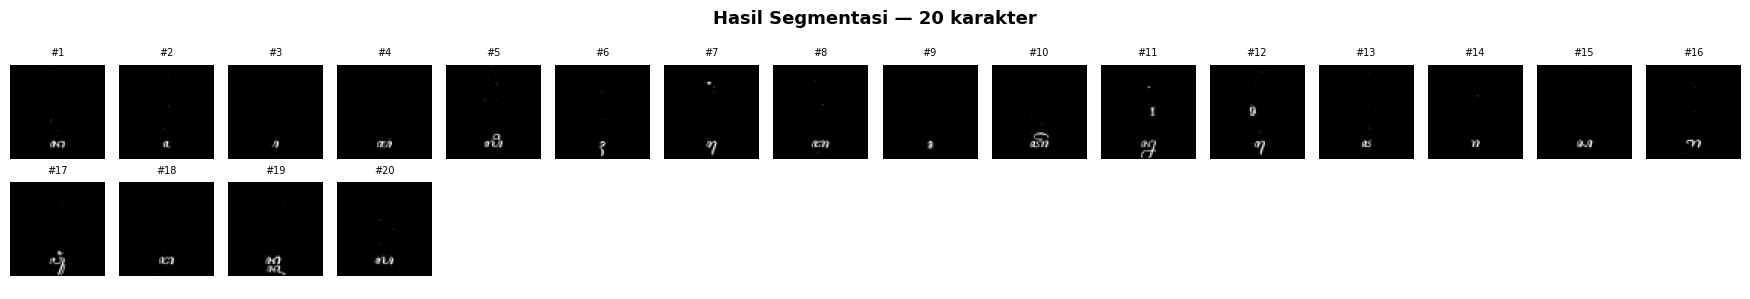

In [ ]:
if len(char_imgs) == 0:
    print("Tidak ada karakter untuk ditampilkan.")
else:
    n     = len(char_imgs)
    ncols = min(n, 16)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 1.1, nrows * 1.5))

    fig.suptitle(f'Hasil Segmentasi — {n} karakter',
                 fontsize=13, fontweight='bold')

    axes = np.array(axes).reshape(nrows, ncols)

    for r in range(nrows):
        for c in range(ncols):
            i = r * ncols + c
            ax = axes[r, c]
            if i < n:
                ax.imshow(char_imgs[i], cmap='gray')
                ax.set_title(f'#{i+1}', fontsize=7)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# folder output
output_folder = "hasil_karakter"
os.makedirs(output_folder, exist_ok=True)

if len(char_imgs) == 0:
    print("Tidak ada karakter untuk disimpan.")
else:
    for i, img in enumerate(char_imgs):
        # pastikan ukuran 64x64 (jika belum)
        img_resized = cv2.resize(img, (64, 64))

        # nama file
        filename = os.path.join(output_folder, f"char_{i+1}.png")

        # simpan gambar
        cv2.imwrite(filename, img_resized)

    print(f"{len(char_imgs)} karakter berhasil disimpan di folder '{output_folder}'")

20 karakter berhasil disimpan di folder 'hasil_karakter'
